In [1]:
"""Image segmentation by point with Segment Anything Model."""

import os
import numpy as np
import matplotlib.pyplot as plt

import cv2
import torch
from segment_anything import sam_model_registry, SamPredictor

In [2]:
IMAGE_DIR = "/Users/pasha/Sources/python/ml/cv/data/evaluate/detection/"
MODEL_PATH = "models/sam_vit_b_01ec64.pth"
MODEL_TYPE = "vit_b"

### Model


In [3]:
class Segmenter:
    def __init__(self, model_type: str, model_path: str):
        self.sam = sam_model_registry[model_type](checkpoint=model_path)
        self.sam.to(device="mps" if torch.backends.mps.is_available() else "cpu")
        self.predictor = SamPredictor(self.sam)

    def segment(
        self, image: np.ndarray, xp: int, yp: int, label: int = 1
    ) -> tuple[np.ndarray, np.ndarray]:
        self.predictor.set_image(image)

        input_point = np.array([[xp, yp]])
        input_label = np.array([label])  # 1 — foreground, 0 — background

        masks, scores, logits = self.predictor.predict(
            point_coords=input_point,
            point_labels=input_label,
            multimask_output=True,
        )
        return masks, scores

### Plot


In [4]:
class PlotStyle:
    width: int = 5
    height: int = 5
    point_color: str = "red"
    point_size: int = 40
    segment_alpha: float = 0.4


def show_segment(
    image: np.ndarray,
    xp: int,
    yp: int,
    mask: np.ndarray,
    score: float,
    style: PlotStyle,
) -> None:
    fig, axes = plt.subplots(1, 1, figsize=(style.width, style.height))
    fig.patch.set_visible(False)
    axes.axis("off")

    axes.imshow(image)
    axes.imshow(mask, alpha=style.segment_alpha)
    axes.scatter(xp, yp, c=style.point_color, s=style.point_size)

    print(f"Score: {score:.3f}")

### Segments search


In [5]:
def find_segment(fn: str, xp: int, yp: int) -> None:
    image = cv2.imread(os.path.join(IMAGE_DIR, fn))
    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    segmenter = Segmenter(MODEL_TYPE, MODEL_PATH)
    masks, scores = segmenter.segment(image, xp, yp)

    style = PlotStyle()
    show_segment(image, xp, yp, masks[0], scores[0], style)

### Demo


Score: 0.938


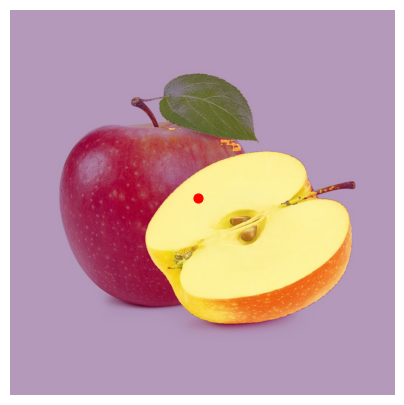

In [6]:
find_segment("2.jpg", 500, 500)

Score: 0.864


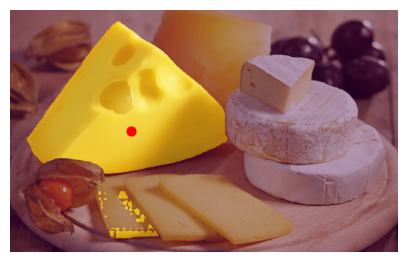

In [7]:
find_segment("3.jpg", 500, 500)

Score: 0.949


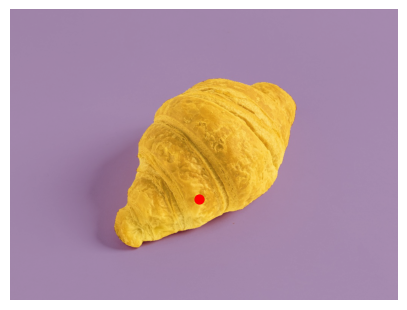

In [8]:
find_segment("5.jpg", 500, 500)

Score: 0.844


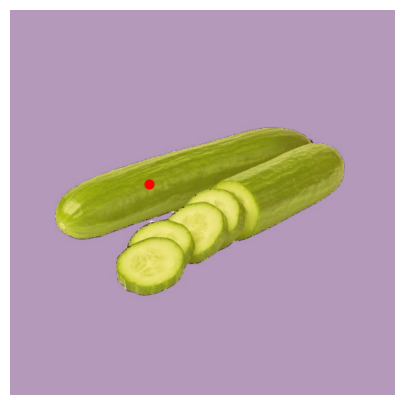

In [9]:
find_segment("6.jpg", 200, 250)

Score: 0.909


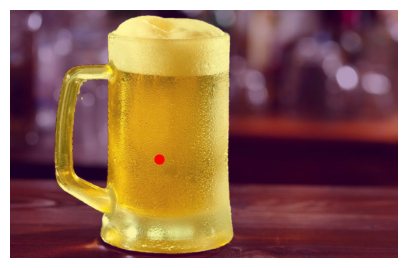

In [10]:
find_segment("8.jpg", 300, 300)